# The committees corpus, with speakers attached

Two datasets, joined:

| repo | what it holds |
|---|---|
| [`ivrit-ai/knesset-committees`](https://huggingface.co/datasets/ivrit-ai/knesset-committees) | the audio and the aligned protocols — 13,176 committee sessions, ~15,500 h. One folder per session (`audio.m4a`, `transcript.aligned.json`, `speakers.txt`, …). |
| [`Dolevabudi/knesset-committees-speakers`](https://huggingface.co/datasets/Dolevabudi/knesset-committees-speakers) | one row per aligned speech segment, **with a global speaker identity attached**. No audio. |

**Why the second dataset exists.** In `knesset-committees` a session's speakers are numbered
`10000000, 10000001, …` in `speakers.txt` — the numbering restarts in every session, so
"speaker 10000000" is a *different person* in every folder. There is no way to collect one
person's speech across sessions. `knesset-committees-speakers` resolves each of those local ids
to the official Knesset **PersonID**, and carries the demographics that come with it.

This notebook shows a complete row, the join into `knesset-committees` that the row stands
for, how an identity was assigned in the first place, and a basic overview of the result. The
column names deliberately mirror VoxKnesset, so `src/common.py` reads this corpus
unchanged.

Nothing here downloads audio. The heaviest cell streams ~130 MB of columns from
`segments.parquet` and takes about a minute.

In [1]:
import time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa, pyarrow.parquet as pq
from huggingface_hub import HfApi, HfFileSystem, hf_hub_download

SPK  = 'Dolevabudi/knesset-committees-speakers'   # segments + identities (this notebook's spine)
COM  = 'ivrit-ai/knesset-committees'              # the audio / protocol repo it points into
PARQ = f'datasets/{SPK}/segments.parquet'

pd.set_option('display.max_colwidth', 70)
pd.set_option('display.width', 200)
plt.rcParams.update({'font.family': ['Arial', 'DejaVu Sans'], 'figure.dpi': 110,
                     'axes.grid': True, 'grid.alpha': .3, 'axes.axisbelow': True})

def rtl(s):
    '''Hebrew for matplotlib: reverse to visual order (matplotlib has no bidi).'''
    return str(s)[::-1]

C:\Users\hadas\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load

In [2]:
# Side tables (small). manifest.csv is the per-session directory of the committees repo.
manifest = pd.read_csv(hf_hub_download(SPK, 'manifest.csv',    repo_type='dataset'))
mks      = pd.read_csv(hf_hub_download(SPK, 'mk_metadata.csv', repo_type='dataset'))
print(f'manifest    {manifest.shape[0]:>7,} sessions   {list(manifest.columns)}')
print(f'mk_metadata {mks.shape[0]:>7,} MKs        {list(mks.columns)}')

manifest     13,176 sessions   ['session_id', 'protocol_name', 'knesset_from_doc', 'has_audio', 'has_refined', 'has_map', 'has_speakers', 'has_segments', 'has_metadata', 'complete', 'has_shard', 'knesset', 'session_number', 'session_date', 'committee_id', 'committee_name', 'in_odata', 'label_path']
mk_metadata     309 MKs        ['person_id', 'first_name', 'last_name', 'gender', 'is_current', 'corpus_full_name', 'date_of_birth', 'place_of_birth', 'year_of_aliya', 'religion', 'nationality', 'religious_orientation', 'residence', 'date_of_death', 'in_corpus', 'full_name']


In [3]:
# segments.parquet is 520 MB, 319 MB of which is reference_text. For the overview we skip the
# text and stream only the columns we plot; strings come back as categories to keep RAM sane.
COLS = ['speaker_id','session','duration_s','quality','label','label_path','match_method',
        'reason','local_speaker_id','knesset','committee_name','session_date','speaker_name',
        'gender','age','date_of_birth','place_of_birth','year_of_aliya','religion',
        'nationality','religious_orientation']

t0 = time.time()
tbl = pq.read_table(PARQ, columns=COLS, filesystem=HfFileSystem())
tbl = tbl.cast(pa.schema([f.with_type(pa.dictionary(pa.int32(), pa.string()))
                          if pa.types.is_large_string(f.type) else f for f in tbl.schema]))
seg = tbl.to_pandas(); del tbl

print(f'{len(seg):,} rows x {seg.shape[1]} cols   '
      f'{seg.memory_usage(deep=True).sum()/1e6:,.0f} MB   {time.time()-t0:.0f}s')

5,158,763 rows x 21 cols   418 MB   23s


## 2. One complete row

`segments.parquet` has 29 columns; the loader above dropped the text to save memory. Here we
pull **one session** back with every column, so a row can be read in full.

In [4]:
SESSION = 2073683   # State Audit Committee, 2018-11-06 — the first session in the manifest

full = pq.read_table(PARQ, filters=[('session', '==', SESSION)],
                     filesystem=HfFileSystem()).to_pandas()
print(f'{len(full):,} segments in session {SESSION}')
full.iloc[0].to_frame('value')

812 segments in session 2073683


,value
filename,4405_2073683_14600_16940.wav
speaker_id,4405
session,2073683
start,14.6
end,16.94
duration_s,2.34
reference_text,שלום לכולם. אני
quality,0.3507
label,mk
label_path,A


In [5]:
show = ['filename','speaker_id','speaker_name','raw_name','local_speaker_id','label',
        'match_method','start','end','duration_s','quality','reference_text']
full[show].head(8)

,filename,speaker_id,speaker_name,raw_name,local_speaker_id,label,match_method,start,end,duration_s,quality,reference_text
0,4405_2073683_14600_16940.wav,4405,שלי יחימוביץ',"היו""ר שלי יחימוביץ",10000000,mk,A,14.60,16.94,2.34,0.3507,שלום לכולם. אני
1,4405_2073683_17600_21060.wav,4405,שלי יחימוביץ',"היו""ר שלי יחימוביץ",10000000,mk,A,17.60,21.06,3.46,0.3844,פותחת את ישיבת הוועדה לענייני ביקורת המדינה.
2,4405_2073683_21580_31220.wav,4405,שלי יחימוביץ',"היו""ר שלי יחימוביץ",10000000,mk,A,21.58,31.22,9.64,0.9376,"אנחנו מתכנסים הבוקר לישיבה מיוחדת ומארחים את ראש המל""ל מאיר בן שבת..."
3,4405_2073683_31800_35160.wav,4405,שלי יחימוביץ',"היו""ר שלי יחימוביץ",10000000,mk,A,31.80,35.16,3.36,0.9332,"בהופעה נדירה וחד פעמית כמעט,"
4,4405_2073683_37000_44960.wav,4405,שלי יחימוביץ',"היו""ר שלי יחימוביץ",10000000,mk,A,37.00,44.96,7.96,0.9980,כדי לדון על הדוח החמור של מבקר המדינה בנושא היעדר המוכנות לרעידות ...
5,4405_2073683_45620_49920.wav,4405,שלי יחימוביץ',"היו""ר שלי יחימוביץ",10000000,mk,A,45.62,49.92,4.30,0.9753,לדיון שאנחנו מטבע הדברים התכוונו לעשות
6,4405_2073683_52280_59580.wav,4405,שלי יחימוביץ',"היו""ר שלי יחימוביץ",10000000,mk,A,52.28,59.58,7.30,0.9961,ביולי מצורף גם דיון מהיר של חברי הכנסת - ואני קוראת אותם לפי הסדר ...
7,4405_2073683_60100_62600.wav,4405,שלי יחימוביץ',"היו""ר שלי יחימוביץ",10000000,mk,A,60.10,62.60,2.50,0.9988,כדי שלא יהיו דיוני קרדיט


## 3. What the row points at in `knesset-committees`

`filename` is a convention, not a file: `{speaker_id}_{session}_{start_ms}_{end_ms}.wav`. The
audio it names is a span inside `{session}/audio.m4a` in the committees repo.

In [6]:
files = HfApi().list_repo_tree(COM, path_in_repo=str(SESSION), repo_type='dataset')
pd.DataFrame([{'file': f.path.split('/')[-1], 'MB': round((f.size or 0)/1e6, 2)}
              for f in files]).sort_values('MB', ascending=False).reset_index(drop=True)

,file,MB
0,audio.m4a,90.56
1,prealign.transcript.json,3.18
2,transcript.aligned.json,3.06
3,transcript.refined.json,2.95
4,speech_probs.frame,1.59
5,transcript.json,0.49
6,transcript.aligned.map.json,0.14
7,metadata.json,0.13
8,20_ptv_519810.doc,0.10
9,raw.full.protocol.txt,0.10


In [7]:
# The session-level row that the committees repo and the speakers dataset agree on.
manifest[manifest.session_id == SESSION].T

,0
session_id,2073683
protocol_name,20_ptv_519810.doc
knesset_from_doc,20
has_audio,True
has_refined,True
has_map,True
has_speakers,True
has_segments,True
has_metadata,True
complete,True


### The problem this dataset solves

`speakers.txt` is what `knesset-committees` gives you: names, and ids that are **local to this
session folder**.

In [8]:
raw = open(hf_hub_download(COM, f'{SESSION}/speakers.txt', repo_type='dataset'),
           encoding='utf-8').read()
print(raw)

10000000	היו"ר שלי יחימוביץ
10000001	מאיר בן שבת
10000002	יצחק סעד
10000003	איילת נחמיאס ורבין (המחנה הציוני)
10000004	סעיד אלחרומי (הרשימה המשותפת)
10000005	מכלוף מיקי זוהר (הליכוד)
10000006	אברהם נגוסה (הליכוד)
10000007	זאב בנימין בגין (הליכוד)
10000008	אהוד סגל
10000009	יוסף ביינהורן
10000010	זאב צוק-רם



In [9]:
# Same session, after the join: every local id carries a global Knesset PersonID.
(full.groupby(['local_speaker_id','raw_name'], observed=True)
     .agg(speaker_id=('speaker_id','max'), speaker_name=('speaker_name','first'),
          label=('label', lambda s: '/'.join(sorted(set(s)))), n_seg=('filename','size'),
          minutes=('duration_s', lambda s: round(s.sum()/60, 1)))
     .reset_index())

,local_speaker_id,raw_name,speaker_id,speaker_name,label,n_seg,minutes
0,10000000,"היו""ר שלי יחימוביץ",4405,שלי יחימוביץ',mk/unresolved,168,13.1
1,10000001,מאיר בן שבת,0,<NA>,non_mk/unresolved,183,15.4
2,10000002,יצחק סעד,0,<NA>,non_mk/unresolved,89,8.4
3,10000003,איילת נחמיאס ורבין (המחנה הציוני),30065,איילת נחמיאס ורבין,mk/unresolved,27,2.0
4,10000004,סעיד אלחרומי (הרשימה המשותפת),30548,סעיד אלחרומי,mk,26,2.1
5,10000005,מכלוף מיקי זוהר (הליכוד),30058,מכלוף מיקי זוהר,mk/unresolved,35,2.3
6,10000006,אברהם נגוסה (הליכוד),30095,אברהם נגוסה,mk,35,1.6
7,10000007,זאב בנימין בגין (הליכוד),2178,זאב בנימין בגין,mk/unresolved,91,6.7
8,10000008,אהוד סגל,0,<NA>,non_mk,38,2.9
9,10000009,יוסף ביינהורן,0,<NA>,non_mk/unresolved,34,3.1


In [10]:
# And the reason the local id alone is useless: 10000000 is a different person every session.
lid = seg[(seg.local_speaker_id == 10000000) & (seg.speaker_id > 0)]
print(f'local id 10000000 appears in {lid.session.nunique():,} sessions '
      f'and resolves to {lid.speaker_id.nunique()} different people')
lid.speaker_name.value_counts().head(8).rename('segments').to_frame()

local id 10000000 appears in 1,450 sessions and resolves to 206 different people


,segments
speaker_name,
נעמה לזימי,8234
משה גפני,4531
יעקב מרגי,4237
אברהם נגוסה,3839
יואב קיש,3069
אלעזר שטרן,2890
עאידה תומא סלימאן,2729
שמחה רוטמן,2710


## 4. How a segment gets an identity

Worth knowing before trusting a `speaker_id`, because it explains every code in `label`,
`match_method` and `reason`. Three independent sources had to agree:

| source | contributes |
|---|---|
| `ivrit-ai/knesset-committees` | the audio, the protocol text, and the word-level alignment between them |
| `HaifaCLGroup/KnessetCorpus` | who said each sentence, plus the MK demographics. No audio |
| the Knesset OData API | who actually held a seat on a given date |

They share one key: Haifa's `person_id` **is** the official Knesset PersonID — the same
numbering VoxKnesset uses, which is why every column here lines up with what
`src/common.py` already expects. Sessions are matched between the first two by the
`.doc` protocol filename, exact string, no fuzzy matching.

**A segment gets an identity only if all three hold:** Haifa attributes that position in the
text to a numeric id (a UUID means guest); the protocol name matches that person after
stripping titles and factions (set equality, not a similarity threshold); and that person was
a seated MK *on that date*. Any one fails → `unresolved`, kept in the data with a `reason`.

**`et_id` is evidence, never a decision.** The stenographer's editor id scored 0.47 accuracy
on its own — id `5794` covers two different people, and Moshe Gafni holds two different ids.
It is carried in the output so decisions can be audited, and nothing more.

Two paths, because Haifa's corpus stops at **2024-03-26**: path **A** aligns text against it;
path **B**, for sessions it does not cover, falls back to exact name matching against the
MKs seated that day, plus a dictionary of (name → person) pairs that path A confirmed.

In [11]:
print('match_method x label   (blank = never attempted)')
print(pd.crosstab(seg.match_method.astype('string').fillna('-'), seg.label))
print('\nreason x label   (blank = resolved)')
print(pd.crosstab(seg.reason.astype('string').fillna('-'), seg.label))

match_method x label   (blank = never attempted)


label              mk   non_mk  unresolved  former_mk
match_method                                         
                    0  1305693     1557098          0
A             1403671        0           0      29978
B1             861682        0           0          0
B2                641        0           0          0

reason x label   (blank = resolved)


label               mk   non_mk  unresolved  former_mk
reason                                                
               2265994        0           0      29978
bad_offset           0        0          84          0
et_conflict          0        0         393          0
gold_guest           0  1305693           0          0
name_disagree        0        0      117038          0
no_gold              0        0      349600          0
no_match             0        0     1083364          0
raw_garbage          0        0        6619          0


In [12]:
# Is the A/B split really the Haifa cutoff? Check it rather than take it on faith.
CUT = '2024-03-26'
by_sess = (seg.groupby('session', observed=True)
              .agg(path=('label_path','first'), date=('session_date','first'))
              .astype('string'))          # 'first' keeps the category dtype; strings compare
print(by_sess.path.value_counts().rename('sessions').to_frame().to_string(), '\n')
print(f'path A sessions after  {CUT}: {(by_sess[by_sess.path=="A"].date > CUT).sum()}')
print(f'path B sessions before {CUT}: {(by_sess[by_sess.path=="B"].date <= CUT).sum()}'
      f'   <- not a clean cut in this direction: pre-cutoff sessions Haifa simply never covered')

      sessions
path          
A         6896
B         4113 

path A sessions after  2024-03-26: 0
path B sessions before 2024-03-26: 309   <- not a clean cut in this direction: pre-cutoff sessions Haifa simply never covered


## 5. Overview of the joined corpus

In [13]:
print(f'rows (segments)  {len(seg):,}')
print(f'audio            {seg.duration_s.sum()/3600:,.0f} h')
print(f'sessions         {seg.session.nunique():,}  of {len(manifest):,} in the committees repo')
print(f'committees       {seg.committee_name.nunique()}')
print(f'knessets         {sorted(seg.knesset.unique())}')
dates = seg.session_date.astype('string')
print(f'dates            {dates.min()} .. {dates.max()}')

by_label = seg.groupby('label', observed=True).agg(
    segments=('duration_s','size'), hours=('duration_s', lambda s: s.sum()/3600),
    speakers=('speaker_id', lambda s: s[s > 0].nunique()))
by_label['% of hours'] = (100*by_label.hours/by_label.hours.sum()).round(1)
by_label.sort_values('hours', ascending=False).round(1)

rows (segments)  5,158,763
audio            8,342 h


sessions         11,009  of 13,176 in the committees repo
committees       150
knessets         [np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]


dates            2018-11-04 .. 2026-01-29


,segments,hours,speakers,% of hours
label,,,,
mk,2265994,3344.9,268,40.1
unresolved,1557098,2687.1,0,32.2
non_mk,1305693,2257.6,0,27.1
former_mk,29978,51.8,165,0.6


`mk` / `former_mk` rows carry an identity; `non_mk` (a guest — an official, an expert) and
`unresolved` (the matcher could not agree on a name) both get `speaker_id = 0`. So a little
under half of the audio is attributable to a named person.

segments below the 0.7 quality floor: 16.7%


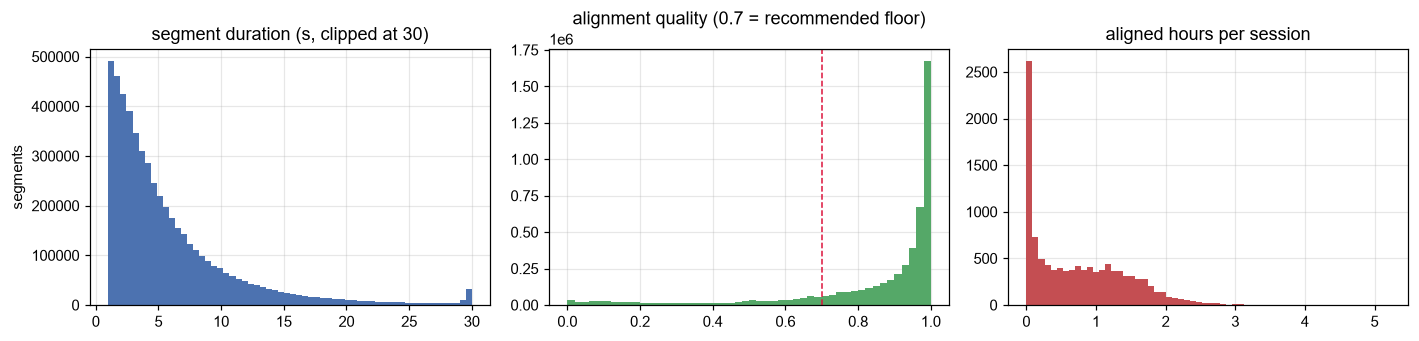

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].hist(seg.duration_s.clip(upper=30), bins=60, color='#4C72B0')
ax[0].set(title='segment duration (s, clipped at 30)', ylabel='segments')
ax[1].hist(seg.quality, bins=50, color='#55A868')
ax[1].axvline(0.7, color='crimson', ls='--', lw=1)
ax[1].set(title='alignment quality (0.7 = recommended floor)')
sess_h = seg.groupby('session', observed=True).duration_s.sum()/3600
ax[2].hist(sess_h, bins=60, color='#C44E52')
ax[2].set(title='aligned hours per session')
fig.tight_layout()

print(f'segments below the 0.7 quality floor: {(seg.quality < 0.7).mean():.1%}')

## 6. How many speakers

In [15]:
named = seg[seg.speaker_id > 0]
print(f'distinct PersonIDs in the corpus : {named.speaker_id.nunique()}')
print(f'  ever seated as MK              : {seg[seg.label=="mk"].speaker_id.nunique()}')
print(f'  appearing only as a former MK  : '
      f'{seg[seg.label=="former_mk"].speaker_id.nunique()}  (overlapping: a person can be both)')
print(f'MKs listed in mk_metadata.csv    : {len(mks)}  '
      f'({mks.in_corpus.sum()} of them appear in the corpus)')
print(f'guests + unresolved (no id)      : '
      f'{(seg.speaker_id == 0).sum():,} segments, '
      f'{seg.duration_s[seg.speaker_id == 0].sum()/3600:,.0f} h')

per_spk = named.groupby('speaker_id', observed=True).agg(
    name=('speaker_name','first'), segments=('duration_s','size'),
    hours=('duration_s', lambda s: s.sum()/3600), sessions=('session','nunique'))
per_spk[['segments','hours','sessions']].describe().round(1)

distinct PersonIDs in the corpus : 339


  ever seated as MK              : 268
  appearing only as a former MK  : 165  (overlapping: a person can be both)
MKs listed in mk_metadata.csv    : 309  (302 of them appear in the corpus)
guests + unresolved (no id)      : 2,862,791 segments, 4,945 h


,segments,hours,sessions
count,339.0,339.0,339.0
mean,6772.8,10.0,132.0
std,14648.4,22.1,186.1
min,2.0,0.0,1.0
25%,244.5,0.3,8.0
50%,1569.0,2.2,50.0
75%,6666.5,10.0,169.0
max,135952.0,220.7,1050.0


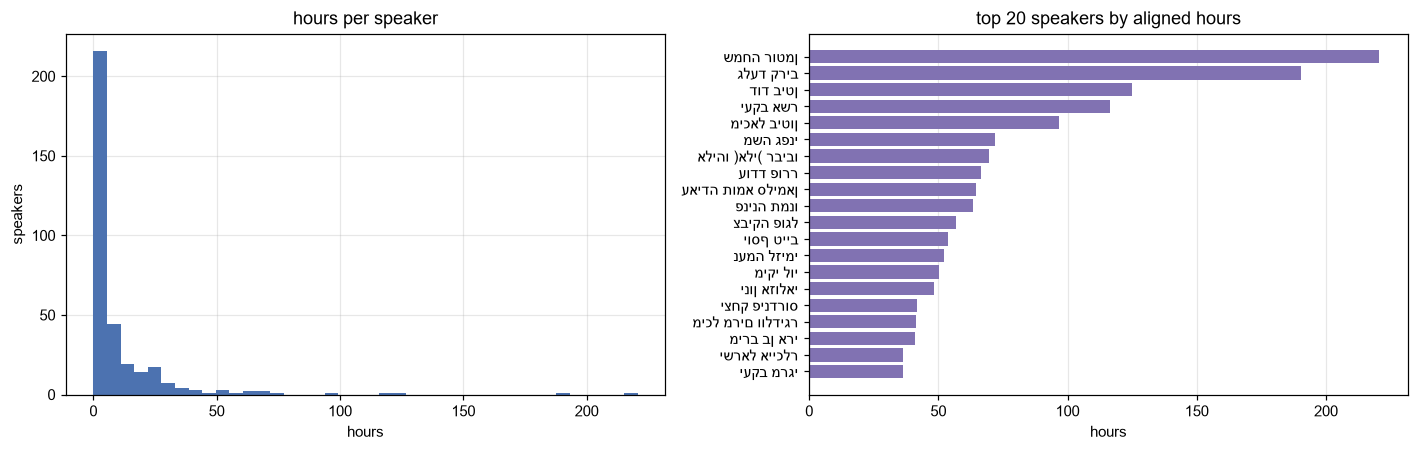

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].hist(per_spk.hours, bins=40, color='#4C72B0')
ax[0].set(title='hours per speaker', xlabel='hours', ylabel='speakers')
top = per_spk.nlargest(20, 'hours').iloc[::-1]
ax[1].barh([rtl(n) for n in top.name], top.hours, color='#8172B2')
ax[1].set(title='top 20 speakers by aligned hours', xlabel='hours')
ax[1].grid(axis='y', alpha=0)
fig.tight_layout()

## 7. Demographics

Two views of every field, because they answer different questions:

* **per speaker** — one vote each, what the panel of people looks like;
* **per hour** — weighted by how much they actually speak, what the *audio* looks like.

Demographics exist only on `mk` / `former_mk` rows.

In [17]:
# One row per identified speaker (demographics are constant per person, except `age`).
spk = (named.groupby('speaker_id', observed=True)
            .agg(name=('speaker_name','first'), gender=('gender','first'),
                 age=('age','median'), date_of_birth=('date_of_birth','first'),
                 place_of_birth=('place_of_birth','first'),
                 year_of_aliya=('year_of_aliya','first'), religion=('religion','first'),
                 nationality=('nationality','first'),
                 religious_orientation=('religious_orientation','first'),
                 hours=('duration_s', lambda s: s.sum()/3600)))
spk['year_of_aliya'] = pd.to_numeric(spk.year_of_aliya.astype('string'), errors='coerce')
print(f'{len(spk)} identified speakers, {spk.hours.sum():,.0f} h')
spk.head()

339 identified speakers, 3,397 h


,name,gender,age,date_of_birth,place_of_birth,year_of_aliya,religion,nationality,religious_orientation,hours
speaker_id,,,,,,,,,,
421,אליעזר כהן,1.0,88.68,1934-06-18,ארץ ישראל,<NA>,יהודי,יהודי,חילוני,0.023922
427,אביגדור ליברמן,1.0,65.36,1958-05-06,ברית המועצות,1978.0,יהודי,יהודי,חילוני,3.995672
431,קולט אביטל,0.0,81.66,1939-05-01,רומניה,1950.0,יהודי,יהודי,NaN,0.429106
441,יעל דיין,0.0,81.76,1939-02-12,ארץ ישראל,<NA>,יהודי,יהודי,חילוני,0.040425
445,איתן כבל,1.0,59.30,1959-08-23,ישראל,<NA>,יהודי,יהודי,חילוני,10.839224


,% of speakers,% of hours
g,,
men,71.7,72.8
women,28.3,27.2


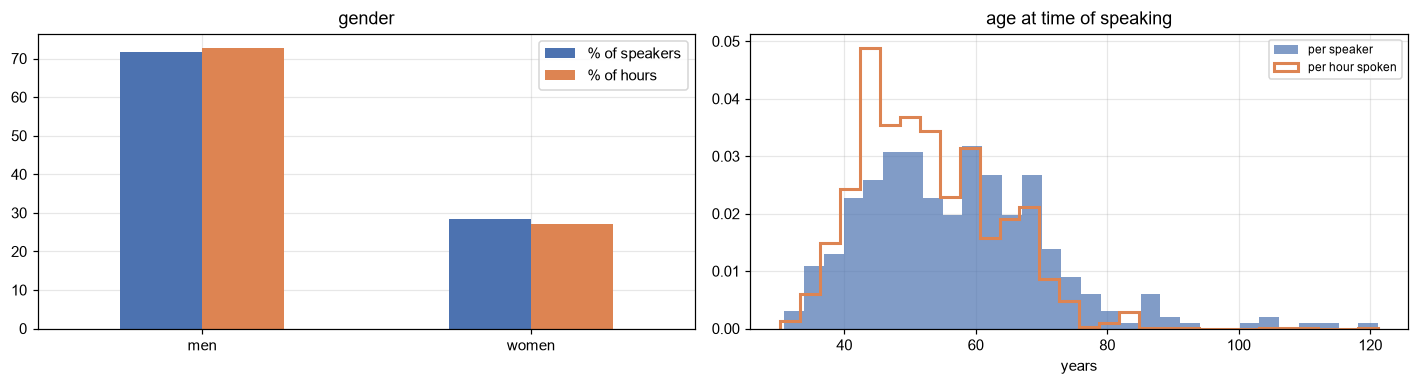

In [18]:
def two_views(field, title, top=None, ax=None):
    '''Bar chart of one categorical field: speakers (count) vs hours spoken.'''
    a = spk.groupby(field, observed=True).agg(speakers=('name','size'), hours=('hours','sum'))
    a = a.sort_values('hours', ascending=False)
    if top: a = a.head(top)
    a = a.iloc[::-1]
    y = np.arange(len(a))
    ax = ax or plt.subplots(figsize=(6, .35*len(a)+1.4))[1]
    ax.barh(y-.2, a.speakers/a.speakers.sum(), .38, label='% of speakers', color='#4C72B0')
    ax.barh(y+.2, a.hours/a.hours.sum(),       .38, label='% of hours',    color='#DD8452')
    ax.set_yticks(y, [rtl(i) for i in a.index]); ax.set_title(title)
    ax.xaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
    ax.grid(axis='y', alpha=0); ax.legend(fontsize=8)
    return ax

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
g = spk.assign(g=spk.gender.map({0: 'women', 1: 'men'})).groupby('g').agg(
        speakers=('name','size'), hours=('hours','sum'))
g_pct = pd.DataFrame({'% of speakers': 100*g.speakers/g.speakers.sum(),
                      '% of hours':    100*g.hours/g.hours.sum()})
g_pct.plot.bar(ax=ax[0], rot=0, color=['#4C72B0','#DD8452'])
ax[0].set(title='gender', xlabel='')
ax[1].hist(spk.age.dropna(), bins=30, color='#4C72B0', density=True, alpha=.7,
           label='per speaker')
ax[1].hist(named.age.dropna(), bins=30, weights=named.duration_s[named.age.notna()],
           density=True, histtype='step', lw=2, color='#DD8452', label='per hour spoken')
ax[1].set(title='age at time of speaking', xlabel='years'); ax[1].legend(fontsize=8)
fig.tight_layout()
g_pct.round(1)

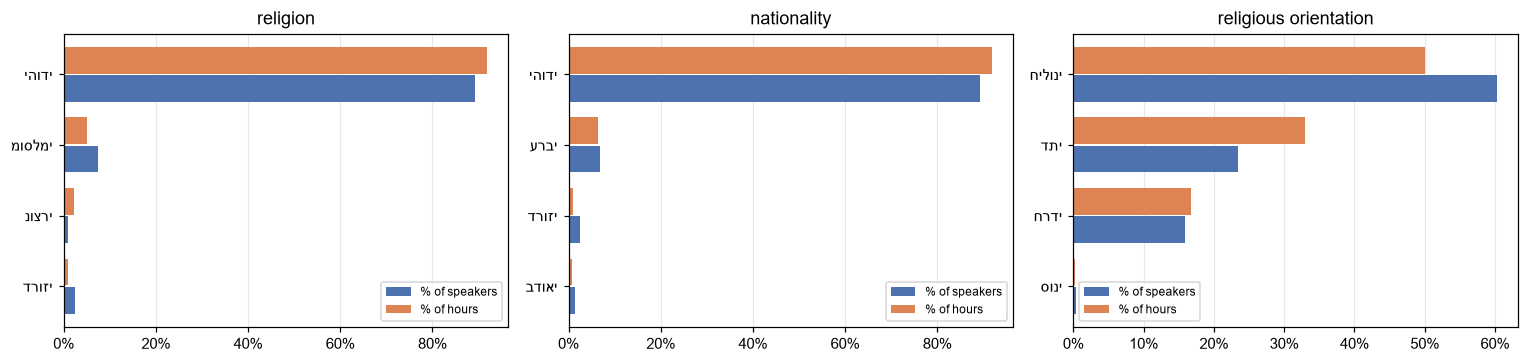

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
two_views('religion',              'religion',              ax=ax[0])
two_views('nationality',           'nationality',           ax=ax[1])
two_views('religious_orientation', 'religious orientation', ax=ax[2])
fig.tight_layout()

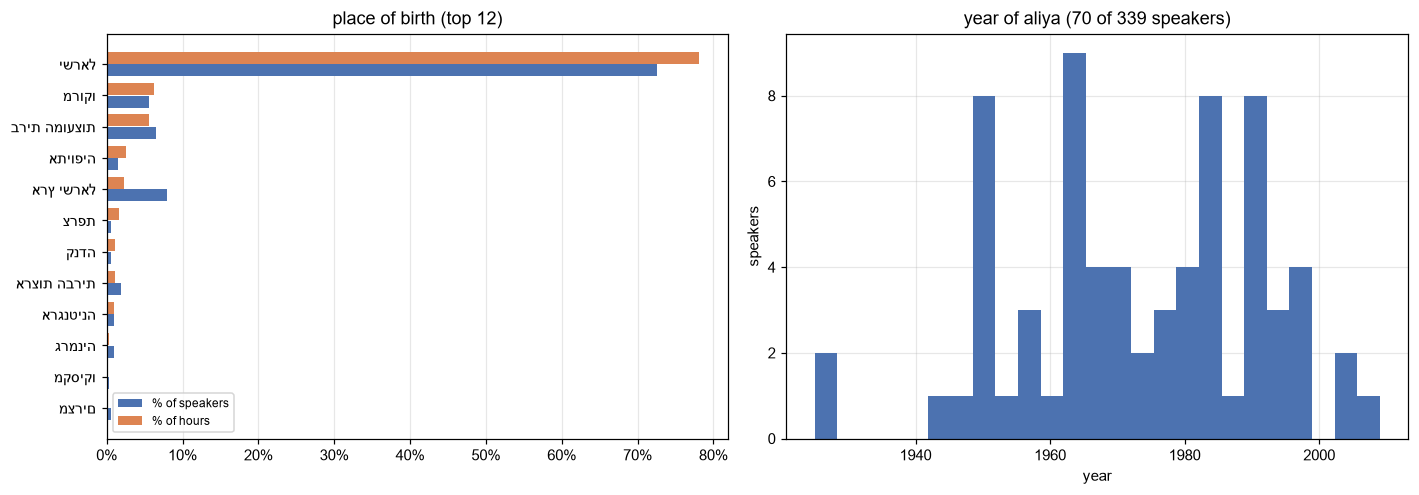

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
two_views('place_of_birth', 'place of birth (top 12)', top=12, ax=ax[0])
ax[1].hist(spk.year_of_aliya.dropna(), bins=25, color='#4C72B0')
ax[1].set(title=f'year of aliya ({spk.year_of_aliya.notna().sum()} of {len(spk)} speakers)',
          xlabel='year', ylabel='speakers')
fig.tight_layout()

## 8. Things to know before using this

**How much to trust an identity.** A 200-session holdout re-ran path B on sessions that *did*
have a protocol and compared against path A: 0 identity errors over 55.4 h, precision 1.00.
That is the strongest number here, and it is worth reading precisely — it says path B does not
attach the wrong person. It does not say the corpus is clean, for the reasons below.

* **Verification is textual only — no voice check has been run yet.** Both text sources descend
  from the same `.doc`, so a mis-attributed heading in the protocol is invisible to any amount
  of cross-checking. Only speaker embeddings would catch it.
* **Sessions after 2024-03-26 are verified by extrapolation.** Haifa's corpus stops there, so
  those sessions have no gold to check against; confidence in them rests on path B scoring
  perfectly where checking *was* possible. That is 1.78 M segments — a third of the corpus.
* **`speaker_id = 0` is not a speaker.** It is the `non_mk` + `unresolved` bucket, 4,945 h,
  59% of the audio. Filter on `label` first. Guests can still be separated *within* a session
  by the pair `(session, local_speaker_id)` — but not across sessions, which is the whole point.
* **Resolution is per segment, not per speaker.** In section 3 the same local id came back
  partly `mk` and partly `unresolved`. Expect gaps inside a speaker's timeline.
* **`quality` is a median word-alignment probability, not a confidence in the identity.** The
  two are unrelated; a perfectly aligned segment can be `unresolved`, and vice versa.
* **`et_id` must never decide anything.** It is the stenographer's editor id, 0.47 accuracy
  standalone, kept only so decisions can be audited. Same for `raw_name`, `local_speaker_id`
  and `gold_speaker_id` — evidence columns, not keys.
* **7 MKs elected in 2025–26 have no demographics** — they postdate Haifa's last update. Blank,
  not wrong.
* **`age` has outliers above 100** (~280 segments, namesake collision) and **`year_of_aliya`
  is a mixed string** (`'1985.0'` and `'1950'`). Clip and coerce.
* **No audio here.** Waveforms mean `hf_hub_download(COM, f'{session}/audio.m4a')`, ~90 MB per
  session, then slicing `[start, end]`.

Two places where the published description and the file disagree, both harmless but worth
knowing: the docs list an `is_chairman` column that **is not in the parquet**, and the parquet
carries a `seg` column that the docs do not mention. And `duration_s` is documented as 1–30 s,
which holds for all but 2 of the 5.16 M rows (max 117.96 s).